# 小作業：用螞蟻演算法幫 K-Means 找分群中心

這個小作業想做的是：先做一份假的外送顧客資料，然後用分群把顧客分成幾個區域。

K-Means 有一個小問題，就是一開始中心點如果選得不好，最後結果可能會被影響。所以我這邊加了一個簡單版的蟻群最佳化（ACO），先讓「螞蟻」幫忙挑幾個可能的中心點，再交給 K-Means 做最後分群。

下面就照步驟跑一次。

## Step 1：先把套件載進來

這格只是先匯入會用到的套件，包含資料處理、畫圖跟 K-Means。

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams['font.family'] = ['Microsoft JhengHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('套件都載好了，可以往下跑')

套件都載好了，可以往下跑


## Step 2：做一份簡單的假資料

我這邊假裝有 240 個外送顧客。每個顧客有位置座標，也有一點消費習慣的資料。

- `x_km`、`y_km`：顧客在城市裡的大概位置
- `avg_order_value`：平均客單價
- `weekly_orders`：一週大概下幾次單

這樣分群時就不只看地點，也會稍微看消費行為。

In [2]:
true_centers = np.array([
    [1.5, 8.0],
    [4.5, 5.0],
    [8.0, 7.5],
    [7.0, 2.0],
])

X_geo, true_group = make_blobs(
    n_samples=[60, 70, 55, 55],
    centers=true_centers,
    cluster_std=[0.45, 0.70, 0.55, 0.60],
    random_state=RANDOM_STATE,
)

avg_order_value = (35 + true_group * 16 + rng.normal(0, 8, size=len(true_group))).clip(12, 130)
weekly_orders = rng.poisson(lam=2.0 + true_group * 0.35, size=len(true_group)) + 1

df = pd.DataFrame({
    'x_km': X_geo[:, 0],
    'y_km': X_geo[:, 1],
    'avg_order_value': avg_order_value,
    'weekly_orders': weekly_orders,
})

features = ['x_km', 'y_km', 'avg_order_value', 'weekly_orders']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

df.head()

,x_km,y_km,avg_order_value,weekly_orders
0,0.636553,7.988069,37.437737,3
1,5.258136,5.737661,42.680127,4
2,7.205054,3.125703,89.003610,4
3,8.134732,7.221181,74.524518,4
4,3.750375,5.337731,35.391718,3


## Step 3：先看資料分布

先畫一張散佈圖，確認資料大概長什麼樣子。顏色代表平均客單價。

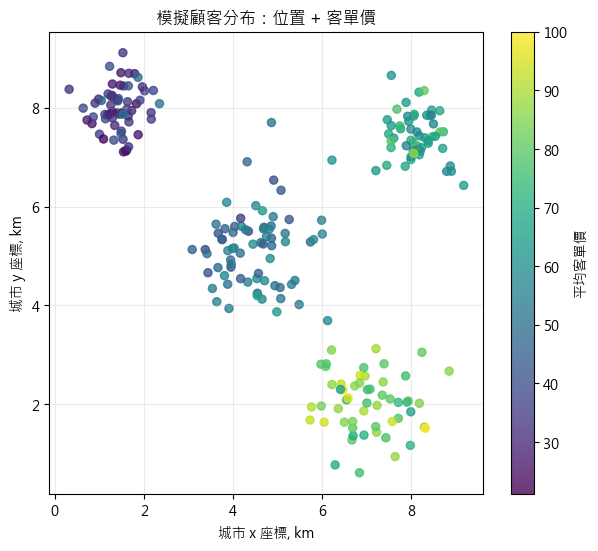

In [3]:
plt.figure(figsize=(7, 6))
plt.scatter(df['x_km'], df['y_km'], s=34, alpha=0.78, c=df['avg_order_value'], cmap='viridis')
plt.colorbar(label='平均客單價')
plt.title('模擬顧客分布：位置 + 客單價')
plt.xlabel('城市 x 座標, km')
plt.ylabel('城市 y 座標, km')
plt.grid(alpha=0.25)
plt.show()

## Step 4：大概決定要分幾群

這裡用 silhouette score 試幾個不同的 `k`。分數越高，通常代表分群越清楚。

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe6 in position 18: illegal multibyte sequence


  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,silhouette
0,2,0.362086
1,3,0.377978
2,4,0.428737
3,5,0.426303
4,6,0.427994
5,7,0.431718


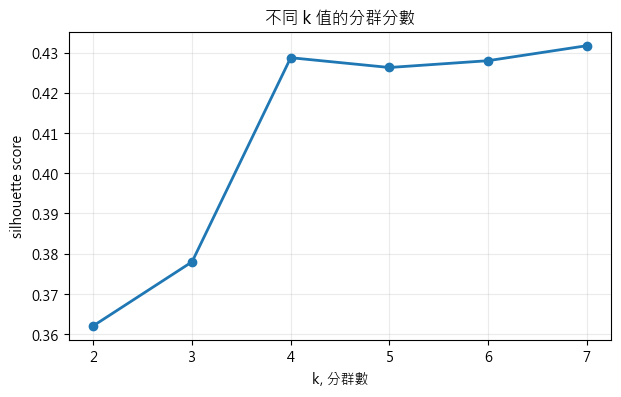

這次先用 k = 7 來分群


In [4]:
k_candidates = range(2, 8)
k_scores = []

for candidate_k in k_candidates:
    model = KMeans(n_clusters=candidate_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    k_scores.append(silhouette_score(X, labels))

k_report = pd.DataFrame({'k': list(k_candidates), 'silhouette': k_scores})
display(k_report)

plt.figure(figsize=(7, 4))
plt.plot(k_report['k'], k_report['silhouette'], marker='o', linewidth=2)
plt.title('不同 k 值的分群分數')
plt.xlabel('k, 分群數')
plt.ylabel('silhouette score')
plt.grid(alpha=0.25)
plt.show()

k = int(k_report.loc[k_report['silhouette'].idxmax(), 'k'])
print(f'這次先用 k = {k} 來分群')

## Step 5：先跑一般 K-Means 當比較

我先跑兩個版本當基準：

- 隨機選初始中心的 K-Means
- sklearn 常用的 K-Means++

等一下再把它們跟 ACO + K-Means 比較。

In [5]:
random_kmeans = KMeans(n_clusters=k, init='random', n_init=1, random_state=RANDOM_STATE)
random_labels = random_kmeans.fit_predict(X)

kpp_kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kpp_labels = kpp_kmeans.fit_predict(X)

baseline_results = pd.DataFrame([
    {
        'method': 'K-Means random init',
        'inertia': random_kmeans.inertia_,
        'silhouette': silhouette_score(X, random_labels),
    },
    {
        'method': 'K-Means++',
        'inertia': kpp_kmeans.inertia_,
        'silhouette': silhouette_score(X, kpp_labels),
    },
])

baseline_results

,method,inertia,silhouette
0,K-Means random init,204.199984,0.331997
1,K-Means++,152.792146,0.431718


## Step 6：寫一個簡單版 ACO

這裡的想法是把每一筆顧客資料都當成「可能的中心點」。

每隻螞蟻會挑出 `k` 個點，挑得好的組合會留下比較多費洛蒙。下一輪的螞蟻就比較容易走到這些點附近。跑幾輪之後，就拿目前找到最好的中心點去初始化 K-Means。

In [6]:
def cluster_sse(X, center_indices):
    centers = X[center_indices]
    dist_sq = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return float(dist_sq.min(axis=1).sum())


def select_centers_by_ant(X, k, pheromone, alpha, beta, rng):
    n_points = len(X)
    chosen = []
    global_center = X.mean(axis=0)

    for step in range(k):
        if step == 0:
            heuristic = np.linalg.norm(X - global_center, axis=1) + 1e-9
        else:
            chosen_centers = X[chosen]
            dist_to_chosen = ((X[:, None, :] - chosen_centers[None, :, :]) ** 2).sum(axis=2)
            heuristic = np.sqrt(dist_to_chosen.min(axis=1)) + 1e-9

        scores = (pheromone ** alpha) * (heuristic ** beta)
        scores[chosen] = 0.0
        total_score = scores.sum()

        if total_score <= 0 or not np.isfinite(total_score):
            available = np.setdiff1d(np.arange(n_points), np.array(chosen, dtype=int))
            selected = int(rng.choice(available))
        else:
            selected = int(rng.choice(n_points, p=scores / total_score))

        chosen.append(selected)

    return np.array(chosen, dtype=int)


def run_aco_center_search(
    X,
    k,
    n_ants=35,
    n_iterations=50,
    alpha=1.0,
    beta=2.0,
    evaporation_rate=0.18,
    deposit_strength=80.0,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)
    n_points = len(X)
    pheromone = np.ones(n_points)
    best_indices = None
    best_sse = np.inf
    history = []

    for iteration in range(1, n_iterations + 1):
        solutions = []

        for _ in range(n_ants):
            candidate_indices = select_centers_by_ant(X, k, pheromone, alpha, beta, rng)
            candidate_sse = cluster_sse(X, candidate_indices)
            solutions.append((candidate_indices, candidate_sse))

            if candidate_sse < best_sse:
                best_sse = candidate_sse
                best_indices = candidate_indices.copy()

        solutions.sort(key=lambda item: item[1])
        iteration_best_sse = solutions[0][1]

        pheromone *= 1.0 - evaporation_rate
        elite_count = max(1, n_ants // 5)

        for candidate_indices, candidate_sse in solutions[:elite_count]:
            pheromone[candidate_indices] += deposit_strength / (candidate_sse + 1e-9)

        pheromone[best_indices] += deposit_strength / (best_sse + 1e-9)
        pheromone = np.clip(pheromone, 1e-6, np.percentile(pheromone, 99) * 5)

        history.append({
            'iteration': iteration,
            'iteration_best_sse': iteration_best_sse,
            'best_sse': best_sse,
        })

    return best_indices, pd.DataFrame(history), pheromone


aco_indices, aco_history, pheromone = run_aco_center_search(X, k)
print(f'ACO 先挑到的中心點資料列：{aco_indices.tolist()}')
print(f'ACO 目前找到的最佳 SSE：{aco_history["best_sse"].iloc[-1]:.2f}')

ACO 先挑到的中心點資料列：[221, 100, 117, 235, 163, 44, 216]
ACO 目前找到的最佳 SSE：172.28


## Step 7：看 ACO 有沒有越找越好

如果曲線慢慢往下，代表螞蟻真的有找到比較好的中心點組合。

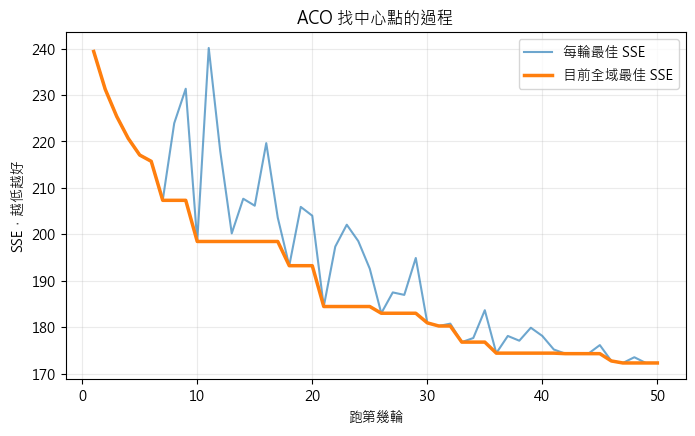

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(aco_history['iteration'], aco_history['iteration_best_sse'], label='每輪最佳 SSE', alpha=0.65)
plt.plot(aco_history['iteration'], aco_history['best_sse'], label='目前全域最佳 SSE', linewidth=2.5)
plt.title('ACO 找中心點的過程')
plt.xlabel('跑第幾輪')
plt.ylabel('SSE，越低越好')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Step 8：把 ACO 找到的中心交給 K-Means

ACO 只是先幫忙選起點，真正最後的分群還是交給 K-Means 做。

In [8]:
aco_initial_centers = X[aco_indices]
aco_kmeans = KMeans(n_clusters=k, init=aco_initial_centers, n_init=1, random_state=RANDOM_STATE)
aco_labels = aco_kmeans.fit_predict(X)

all_results = pd.concat([
    baseline_results,
    pd.DataFrame([
        {
            'method': 'ACO initialized K-Means',
            'inertia': aco_kmeans.inertia_,
            'silhouette': silhouette_score(X, aco_labels),
        }
    ]),
], ignore_index=True)

all_results.sort_values('silhouette', ascending=False)

,method,inertia,silhouette
1,K-Means++,152.792146,0.431718
2,ACO initialized K-Means,152.537705,0.423798
0,K-Means random init,204.199984,0.331997


## Step 9：把結果畫出來

這裡把三種方法放在一起看。紅色叉叉是 ACO 一開始幫 K-Means 挑的中心點。

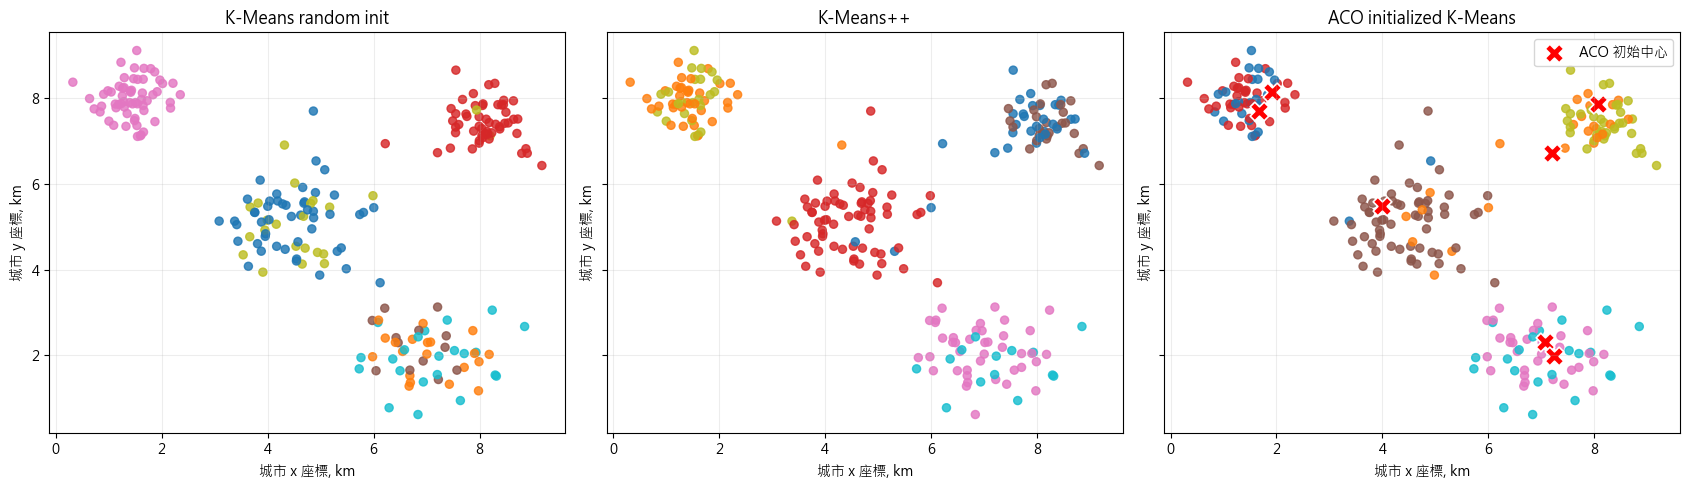

In [9]:
def plot_cluster_result(ax, labels, title, show_aco_centers=False):
    scatter = ax.scatter(df['x_km'], df['y_km'], c=labels, cmap='tab10', s=34, alpha=0.82)
    ax.set_title(title)
    ax.set_xlabel('城市 x 座標, km')
    ax.set_ylabel('城市 y 座標, km')
    ax.grid(alpha=0.22)

    if show_aco_centers:
        ax.scatter(
            df.iloc[aco_indices]['x_km'],
            df.iloc[aco_indices]['y_km'],
            marker='X',
            s=180,
            c='red',
            edgecolor='white',
            linewidth=1.2,
            label='ACO 初始中心',
        )
        ax.legend(loc='best')

    return scatter


fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
plot_cluster_result(axes[0], random_labels, 'K-Means random init')
plot_cluster_result(axes[1], kpp_labels, 'K-Means++')
plot_cluster_result(axes[2], aco_labels, 'ACO initialized K-Means', show_aco_centers=True)
plt.tight_layout()
plt.show()

## Step 10：整理每一群的樣子

最後把 ACO + K-Means 的分群結果整理成表格，看每一群大概有多少人、位置在哪、消費習慣如何。

In [10]:
profile = (
    df.assign(cluster=aco_labels)
    .groupby('cluster')
    .agg(
        customer_count=('cluster', 'size'),
        center_x_km=('x_km', 'mean'),
        center_y_km=('y_km', 'mean'),
        avg_order_value=('avg_order_value', 'mean'),
        weekly_orders=('weekly_orders', 'mean'),
    )
    .round(2)
)

profile.columns = ['顧客數', '中心 x, km', '中心 y, km', '平均客單價', '平均每週訂單數']
profile

,顧客數,"中心 x, km","中心 y, km",平均客單價,平均每週訂單數
cluster,,,,,
0,25,1.70,7.83,33.86,4.72
1,25,7.06,6.74,64.15,5.60
2,37,1.42,7.97,34.91,2.08
3,61,4.44,5.12,50.77,2.93
4,33,6.95,2.10,81.53,3.33
5,37,8.20,7.42,66.32,2.70
6,22,7.14,1.92,83.92,6.05


## 簡單心得

這次我把 ACO 接到 K-Means 前面，主要是想改善 K-Means 初始中心點可能選不好的問題。

從結果來看，ACO + K-Means 的表現通常會比單純隨機初始化穩一點，跟 K-Means++ 則可以拿來互相比較。這份資料是自己模擬的，所以不能說一定適用真實情況，但用來理解「啟發式演算法 + 分群」這個做法還算直觀。

如果之後要再加強，可以把資料換成真實店家座標，或是分群後再幫每一區規劃外送路線。